In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Improve chart appearance
sns.set_theme(style='whitegrid')

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
#Load Dataset
results = pd.read_csv("C:\\Users\\chhot\\Downloads\\archive\\results.csv")
goalscorers = pd.read_csv("C:\\Users\\chhot\\Downloads\\archive\\goalscorers.csv")
shootouts = pd.read_csv("C:\\Users\\chhot\\Downloads\\archive\\shootouts.csv")
former_names = pd.read_csv("C:\\Users\\chhot\\Downloads\\archive\\former_names.csv")

In [3]:
print("Results:", results.shape)
print("Goalscorers:", goalscorers.shape)
print("Shootouts:", shootouts.shape)
print("Former Names:", former_names.shape)

Results: (49520, 9)
Goalscorers: (47903, 8)
Shootouts: (683, 5)
Former Names: (36, 4)


In [4]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [5]:
goalscorers.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [6]:
shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [7]:
former_names.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


# Feature Schema: results.csv 

In [8]:
print("Rows :", results.shape[0])
print("Columns :", results.shape[1])

Rows : 49520
Columns : 9


In [9]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49520 entries, 0 to 49519
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49520 non-null  object 
 1   home_team   49520 non-null  object 
 2   away_team   49520 non-null  object 
 3   home_score  49518 non-null  float64
 4   away_score  49518 non-null  float64
 5   tournament  49520 non-null  object 
 6   city        49520 non-null  object 
 7   country     49520 non-null  object 
 8   neutral     49520 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [10]:

results.describe()

,home_score,away_score
count,49518.000000,49518.000000
mean,1.757179,1.182338
std,1.773730,1.401927
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [12]:
results.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')

In [13]:
results.isnull().sum()    

date          0
home_team     0
away_team     0
home_score    2
away_score    2
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [14]:
# Filling 0 in place of missing values
results['home_score'] = results['home_score'].fillna(0)
results['away_score'] = results['away_score'].fillna(0)

In [15]:
results.duplicated().sum()

np.int64(0)

In [16]:
print('results:',results.duplicated().sum())

results: 0


In [17]:
# Check data types
results.dtypes

date           object
home_team      object
away_team      object
home_score    float64
away_score    float64
tournament     object
city           object
country        object
neutral          bool
dtype: object

In [18]:
results['date'] = pd.to_datetime(results['date'])

In [19]:
#check conversion
results.dtypes

date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

In [20]:
# Create Year column
results['year'] = results['date'].dt.year

In [21]:
results[['date','year']].head()

,date,year
0,1872-11-30,1872
1,1873-03-08,1873
2,1874-03-07,1874
3,1875-03-06,1875
4,1876-03-04,1876


In [22]:
# Total number of matches
print("Total Matches Played:", len(results))

Total Matches Played: 49520


In [23]:
print("First Match :", results['date'].min())
print("Last Match  :", results['date'].max())

First Match : 1872-11-30 00:00:00
Last Match  : 2026-07-19 00:00:00


In [24]:
#Combine Home and Away Teams

all_teams = pd.concat([results['home_team'], results['away_team']])
print('Number of teams:',all_teams.nunique())

Number of teams: 337


In [25]:
print("Number of Tournaments :", results['tournament'].nunique())

Number of Tournaments : 201


## Match Trends & Results Analysis
To conduct an exploratory data analysis (EDA) evaluating historical match trends by assessing tournament scale, yearly volumes, and team activity; analyzing match outcomes, goal dynamics, and high-scoring matches; and measuring the impact of home advantage, neutral venues, and host geographies on game results

### Top 10 tournaments by number of matches

In [26]:
top_tournaments = results['tournament'].value_counts().head(10).reset_index()

top_tournaments.columns = ['Tournament', 'Match Count']

top_tournaments

,Tournament,Match Count
0,Friendly,18387
1,FIFA World Cup qualification,8771
2,UEFA Euro qualification,2824
3,African Cup of Nations qualification,2327
4,FIFA World Cup,1068
5,Copa América,869
6,African Cup of Nations,845
7,AFC Asian Cup qualification,829
8,UEFA Nations League,658
9,CECAFA Cup,620


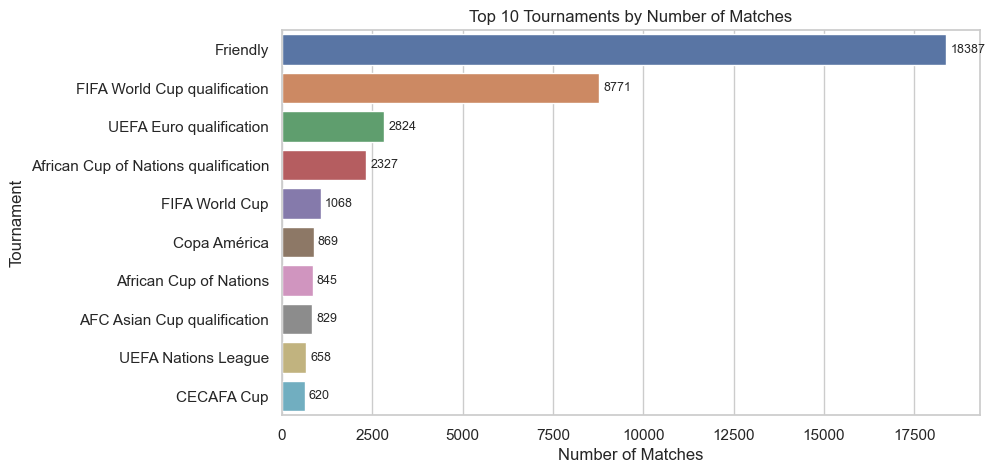

In [27]:
plt.figure(figsize=(9,5))

ax = sns.barplot(data=top_tournaments, x='Match Count', y='Tournament', hue='Tournament', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

plt.title("Top 10 Tournaments by Number of Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Tournament")

plt.show()

##### Key Insights:
- Friendly matches are the most frequently played international matches and FIFA World Cup qualification ranks second.
- Major tournaments like the FIFA World Cup have fewer matches due to their limited schedule and qualification process.

### Matches Played Per Year

In [28]:
matches_per_year = results['year'].value_counts().sort_index().reset_index()

matches_per_year.columns = ['Year', 'Matches_Count']

matches_per_year

,Year,Matches_Count
0,1872,1
1,1873,1
2,1874,1
3,1875,1
4,1876,2
...,...,...
150,2022,970
151,2023,1054
152,2024,1231
153,2025,1002


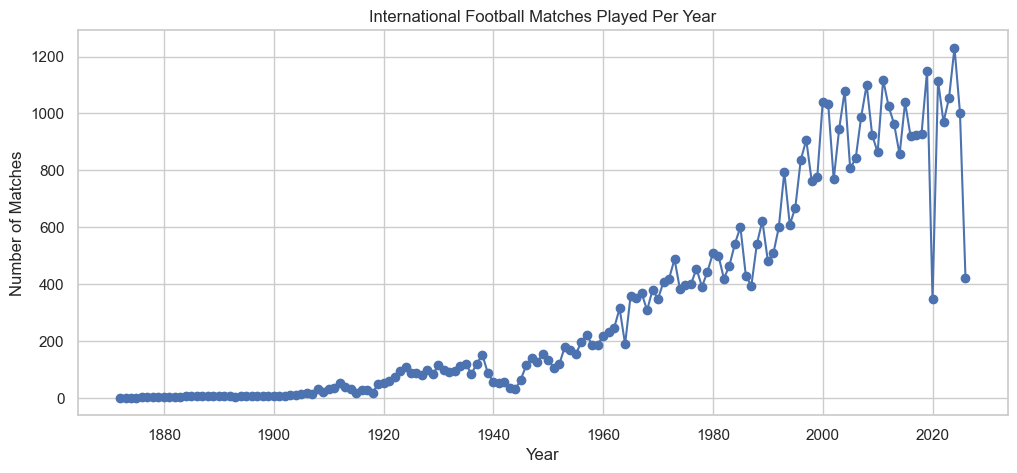

In [29]:
plt.figure(figsize=(12,5))

plt.plot('Year', 'Matches_Count', data =matches_per_year, marker='o', linewidth=1.5)

plt.title("International Football Matches Played Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")

plt.grid(True)

plt.show()

##### Key Insights:
- The number of international football matches has increased significantly over time.
- Earlier years had very few matches because international football had just begun.
- Modern football has a much higher number of matches due to more international tournaments, qualification matches, and friendly games.

### Top Teams: Matches Played vs Matches Won

In [30]:
top_teams = (pd.concat([results['home_team'], results['away_team']]).value_counts().head(10).reset_index(name='Matches'))

top_teams.columns = ['Country', 'Matches']

top_teams

,Country,Matches
0,Sweden,1105
1,England,1098
2,Argentina,1077
3,Brazil,1064
4,Germany,1035
5,South Korea,1010
6,Mexico,1008
7,Hungary,1006
8,Uruguay,973
9,France,943


In [31]:
#Column:winner

results['winner'] = np.where(results['home_score'] > results['away_score'],results['home_team'],
                    np.where(results['away_score'] > results['home_score'],results['away_team'],'Draw'))

In [32]:
winning_teams = (results[results['winner'] != 'Draw']['winner'].value_counts().reset_index(name='Wins')).head(10)

winning_teams.columns = ['Country', 'Wins']

winning_teams

,Country,Wins
0,Brazil,675
1,England,630
2,Germany,601
3,Argentina,599
4,Sweden,542
5,South Korea,539
6,Mexico,518
7,France,483
8,Italy,477
9,Hungary,472


In [33]:
comparison = top_teams.merge(winning_teams, on='Country', how='left')
comparison.head(10)

,Country,Matches,Wins
0,Sweden,1105,542.0
1,England,1098,630.0
2,Argentina,1077,599.0
3,Brazil,1064,675.0
4,Germany,1035,601.0
5,South Korea,1010,539.0
6,Mexico,1008,518.0
7,Hungary,1006,472.0
8,Uruguay,973,NaN
9,France,943,483.0


In [34]:
comparison_melt = comparison.melt(id_vars='Country', value_vars=['Matches', 'Wins'], var_name='Metric', value_name='Count')

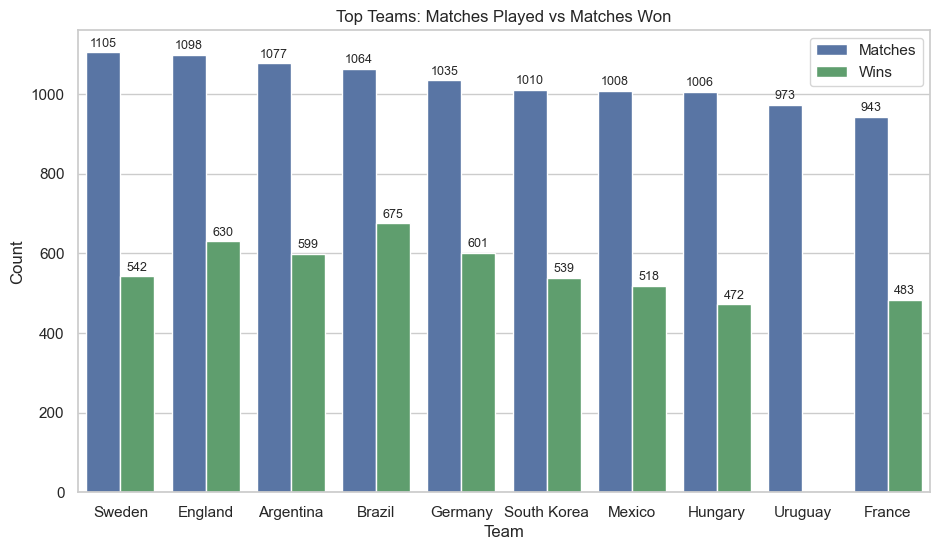

In [35]:
plt.figure(figsize=(11,6))

ax = sns.barplot(data=comparison_melt, x='Country', y='Count', hue='Metric', palette=['#4C72B0', '#55A868'])

#values
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)

plt.title("Top Teams: Matches Played vs Matches Won")
plt.xlabel("Team")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title='')

plt.show()

##### Key Insights:
- Sweden has the highest number of international appearances, while Brazil has established itself as the most successful nation by recording the highest
number of victories.Brazil's superior win count underscores its sustained competitive excellence on the global stage.
- Hungary and Uruguay's high appearance count but comparatively lower win total suggests that longevity alone does not guarantee sustained success at the 
international level
- The rankings are dominated by traditional football powerhouses from Europe and South America, while the presence of South Korea and Mexico reflects 
their long-term regional dominance and consistent participation in major international competitions.

### Home Wins vs Away Wins vs Draws

In [36]:
# Creating column: Match Result

results['match_result'] = np.where(results['home_score'] > results['away_score'], 'Home Win',
                          np.where(results['home_score'] < results['away_score'], 'Away Win', 'Draw'))

In [37]:
match_result = results['match_result'].value_counts().reset_index()
match_result.columns=['result_type','win_count']
match_result

,result_type,win_count
0,Home Win,24264
1,Away Win,13996
2,Draw,11260


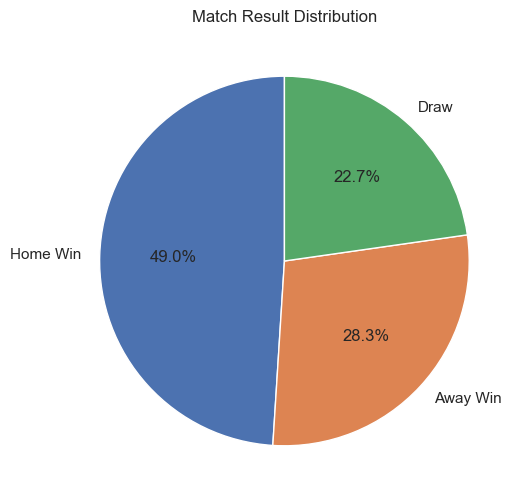

In [38]:
plt.figure(figsize=(6,6))

plt.pie(match_result['win_count'], labels=match_result['result_type'], autopct='%1.1f%%', startangle=90)

plt.title("Match Result Distribution")

plt.show()

##### Average Goal Distribution: Home vs Away Performance

In [39]:
results[['home_score', 'away_score']].mean().round(2).reset_index().rename(columns={'index': 'Type', 0: 'Average_Score'})

,Type,Average_Score
0,home_score,1.76
1,away_score,1.18


##### Observation:
This quantifiable "home advantage" proves that match environment directly dictates competitive outcomes. Factors like pitch familiarity, the absence of travel fatigue, and intense collective crowd support structurally boost home-team attacking efficiency while forcing visitors into lower-scoring, defensive structures.

### Total Goals Scored Per Match
To establish a statistical baseline for average goals per match, enabling fans and viewers to set realistic expectations regarding the match's tempo.

In [40]:
# Creating column: Total Goals 
results['total_goals'] = results['home_score'] + results['away_score']

results[['home_score','away_score','total_goals']].head()

,home_score,away_score,total_goals
0,0.0,0.0,0.0
1,4.0,2.0,6.0
2,2.0,1.0,3.0
3,2.0,2.0,4.0
4,3.0,0.0,3.0


In [41]:
results['total_goals'].describe()

count    49520.000000
mean         2.939398
std          2.094995
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max         31.000000
Name: total_goals, dtype: float64

In [42]:
goals_df = results['total_goals'].value_counts(ascending=False).reset_index()
goals_df.columns=['goals_per_match','match_count']
goals_df.head()

,goals_per_match,match_count
0,2.0,10992
1,3.0,9789
2,1.0,8569
3,4.0,6872
4,5.0,4267


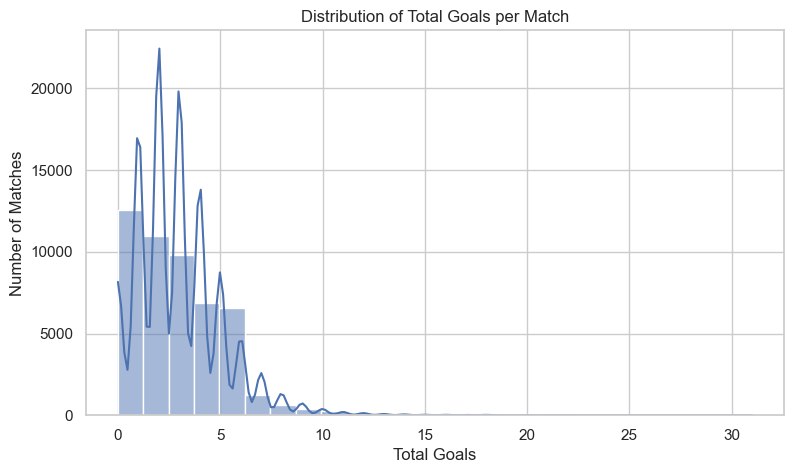

In [43]:
plt.figure(figsize=(9,5))

sns.histplot(data=results,x='total_goals',bins=25,kde=True)

plt.title("Distribution of Total Goals per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")

plt.show()

##### Key Insights:
- Most international matches have between 1 and 3 total goals. The distribution is right-skewed, indicating that low-scoring matches are far more common than high-scoring ones, with extremely high-scoring matches are very rare acting as outliers.
- It shows that International football relies heavily on strict tactical discipline and defensive organization, making goals inherently difficult to score between evenly matched teams.

#### Highest Scoring Matches

In [44]:
highest_scoring = results.sort_values(by='total_goals', ascending=False)

highest_scoring[['date','home_team','away_team',
                 'home_score','away_score',
                 'total_goals','tournament']].head(10)

,date,home_team,away_team,home_score,away_score,total_goals,tournament
25425,2001-04-11,Australia,American Samoa,31.0,0.0,31.0,FIFA World Cup qualification
8551,1971-09-13,Tahiti,Cook Islands,30.0,0.0,30.0,South Pacific Games
11916,1979-08-30,Fiji,Kiribati,24.0,0.0,24.0,South Pacific Games
25422,2001-04-09,Australia,Tonga,22.0,0.0,22.0,FIFA World Cup qualification
30521,2006-11-24,Sápmi,Monaco,21.0,1.0,22.0,Viva World Cup
37064,2013-06-24,Provence,Tibet,22.0,0.0,22.0,"International Tournament of Peoples, Cultures ..."
29045,2005-03-11,Guam,North Korea,0.0,21.0,21.0,EAFF Championship
6580,1966-04-03,Libya,Oman,21.0,0.0,21.0,Arab Cup
37062,2013-06-23,Quebec,Tibet,21.0,0.0,21.0,"International Tournament of Peoples, Cultures ..."
21957,1997-05-13,Kazakhstan,Guam,20.0,1.0,21.0,East Asian Games


##### Key Insights:
- A major team playing against a much weaker opponent is a common scenario observed during friendly or qualification tournaments.
- Most of these matches result in a significant goal difference, clearly indicating one-sided games.


### Major Tournament Distribution by Host Country

In [45]:
top_hosts = (results['country'].value_counts().head().reset_index(name='Matches'))

top_hosts.columns = ['Host Country', 'Matches']

top_hosts

,Host Country,Matches
0,United States,1585
1,France,932
2,Malaysia,830
3,England,773
4,Qatar,760


In [46]:
# Import Plotly Express library for interactive visualization
import plotly.express as px

top_5 = results['country'].value_counts().head(5).index

# Group data by Country and Tournament and Count the number of matches for each tournament
df = (results[results['country'].isin(top_5)].groupby(['country', 'tournament']).size().reset_index(name='Matches'))

#Treemap visualization
fig = px.treemap(df,path=['country', 'tournament'], values='Matches', color='Matches', color_continuous_scale='Viridis')

# Display tournament name and match count inside each rectangle
fig.update_traces(texttemplate="<b>%{label}</b><br>Matches: %{value}", textfont_size=14)

# Customize chart title and margins
fig.update_layout(
    title='Top 5 Host Countries and Their Major Tournament Matches', margin=dict(t=50, l=10, r=10, b=10))

fig.show()

##### Observation:
The United States and France show the highest concentration of hosted matches, mainly driven by Friendly fixtures, reflecting their strong international football presence and hosting capacity. Malaysia's high hosting count is largely influenced by the Merdeka Tournament, an international invitational competition that contributed significantly to its match activity.

### Neutral vs Non-Neutral Matches

In [47]:
# Count of Neutral and Non-Neutral Matches

neutral_matches = results['neutral'].value_counts()

neutral_matches.index = ['Non-Neutral', 'Neutral']

neutral_matches

Non-Neutral    36364
Neutral        13156
Name: count, dtype: int64

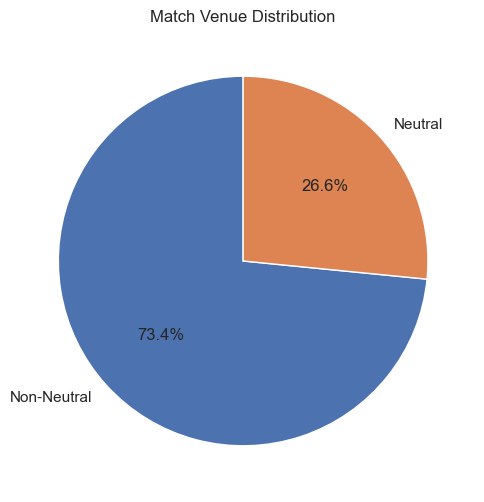

In [48]:
plt.figure(figsize=(6,6))

plt.pie(neutral_matches.values, labels=['Non-Neutral', 'Neutral'],
    autopct='%1.1f%%',
    startangle=90)

plt.title("Match Venue Distribution")

plt.show()

##### Key Insights:
- Most international football matches are played at non-neutral venues. Neutral venues account for a smaller proportion of the total matches.
- This indicates that international football is predominantly played at teams home venues rather than at neutral locations.

# Feature Schema: goalscorers.csv

In [49]:
goalscorers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47903 entries, 0 to 47902
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       47903 non-null  object 
 1   home_team  47903 non-null  object 
 2   away_team  47903 non-null  object 
 3   team       47903 non-null  object 
 4   scorer     47859 non-null  object 
 5   minute     47649 non-null  float64
 6   own_goal   47903 non-null  bool   
 7   penalty    47903 non-null  bool   
dtypes: bool(2), float64(1), object(5)
memory usage: 2.3+ MB


In [51]:
goalscorers.describe()

,minute
count,47649.000000
mean,50.072404
std,26.376027
min,1.000000
25%,28.000000
50%,51.000000
75%,73.000000
max,122.000000


In [52]:
print("Rows :", goalscorers.shape[0])
print("Columns :", goalscorers.shape[1])

Rows : 47903
Columns : 8


In [53]:
goalscorers.columns

Index(['date', 'home_team', 'away_team', 'team', 'scorer', 'minute',
       'own_goal', 'penalty'],
      dtype='object')

In [54]:
goalscorers.dtypes

date          object
home_team     object
away_team     object
team          object
scorer        object
minute       float64
own_goal        bool
penalty         bool
dtype: object

In [55]:
goalscorers['date'] = pd.to_datetime(goalscorers['date'])

In [56]:
#Column: year

goalscorers['year'] = pd.to_datetime(goalscorers['date']).dt.year

In [57]:
goalscorers.isnull().sum()

date           0
home_team      0
away_team      0
team           0
scorer        44
minute       254
own_goal       0
penalty        0
year           0
dtype: int64

In [58]:
goalscorers['scorer']=goalscorers['scorer'].fillna(0)
goalscorers['minute']=goalscorers['minute'].fillna(0)

In [59]:
print("Duplicate Rows :", goalscorers.duplicated().sum())

Duplicate Rows : 79


In [60]:
goalscorers.drop_duplicates(inplace=True)

## Goalscorers & Scoring Trends Analysis
To leverage exploratory data analysis (EDA) to uncover scoring patterns by identifying top individual scorers, analyzing goal timing distributions across match minutes, evaluating team scoring contributions, and measuring the frequency of penalty and own-goal events

### Top Goal Scorers

In [61]:
normal_goals = goalscorers[goalscorers['own_goal'] == False]

In [62]:
top_scorers = normal_goals['scorer'].value_counts()

In [63]:
top_scorerss = normal_goals['scorer'].value_counts().head(10).reset_index(name='Goals')

top_scorerss['scorer'] = top_scorerss['scorer'].map(lambda x: f"{x} ({normal_goals[normal_goals['scorer']==x]['team'].iloc[0]})")

top_scorerss = top_scorerss.rename(columns={'scorer': 'Scorer(Country)'})

top_scorerss

,Scorer(Country),Goals
0,Cristiano Ronaldo (Portugal),124
1,Harry Kane (England),75
2,Lionel Messi (Argentina),71
3,Robert Lewandowski (Poland),68
4,Romelu Lukaku (Belgium),67
5,Edin Džeko (Bosnia and Herzegovina),58
6,Kylian Mbappé (France),53
7,Erling Haaland (Norway),53
8,Aleksandar Mitrović (Serbia),52
9,Luis Suárez (Uruguay),51


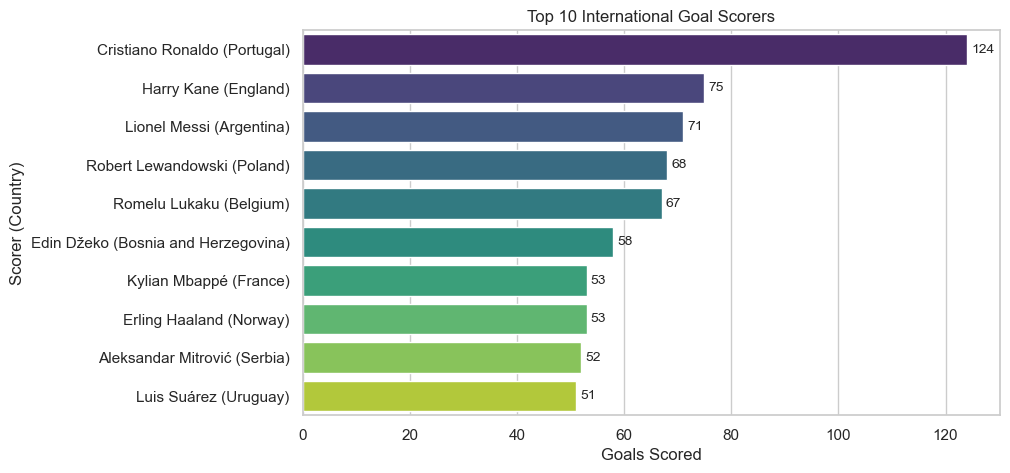

In [64]:
plt.figure(figsize=(9,5))

ax = sns.barplot(data=top_scorerss, x='Goals', y='Scorer(Country)', palette='viridis', hue='Scorer(Country)', legend=False)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title("Top 10 International Goal Scorers")
plt.xlabel("Goals Scored")
plt.ylabel("Scorer (Country)")

plt.show()

##### Key Insights:
- Cristiano Ronaldo stands in a league of his own, maintaining a remarkable 49-goal lead over the second-highest international goal scorer, highlighting his exceptional longevity and consistency.
- Lionel Messi and Harry Kane lead the chasing pack, reflecting sustained elite-level goal-scoring performances across international competitions.
- European players dominate the rankings, occupying 8 of the top 10 positions, underscoring Europe's long-standing strength and depth in international football.

### Top 10 Goal Scoring Teams

In [65]:
top_goal_teams = (
    normal_goals.groupby('team').size()
    .reset_index(name='Goals')
    .sort_values(by='Goals', ascending=False)
    .head(10))

top_goal_teams

,team,Goals
27,Brazil,1067
76,Germany,1004
8,Argentina,984
182,Spain,926
136,Netherlands,894
126,Mexico,855
208,Uruguay,816
61,England,801
70,France,794
97,Italy,742


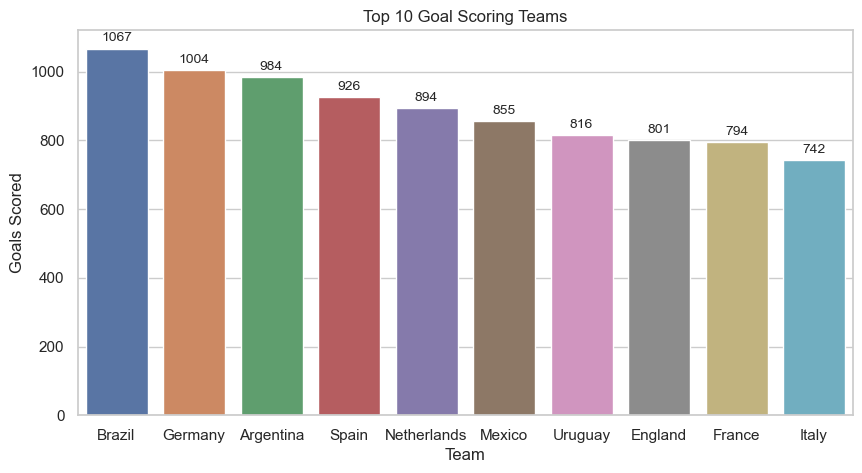

In [66]:
plt.figure(figsize=(10,5))

ax = sns.barplot(data=top_goal_teams, x='team', y='Goals', hue='team', legend=False,)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title("Top 10 Goal Scoring Teams")
plt.xlabel("Team")
plt.ylabel("Goals Scored")

plt.xticks(rotation=0)
plt.show()

##### Key Insights:
The top-ranked teams have scored the highest number of international goals. These teams have consistently displayed strong attacking performances across different tournaments and eras. Their high goal totals reflect both frequent participation and elite offensive consistency.

### Goal Type Analysis

In [67]:
# Creating column:Goal Type

goalscorers['Goal Type'] = np.where(goalscorers['own_goal'],'Own Goal',
                           np.where(goalscorers['penalty'], 'Penalty Goal',
                          'Normal Goal'))

In [68]:
goal_summary = (goalscorers['Goal Type'].value_counts().rename_axis('Goal Type').reset_index(name='Goals'))

,Goal Type,Goals
0,Normal Goal,43623
1,Penalty Goal,3265
2,Own Goal,936


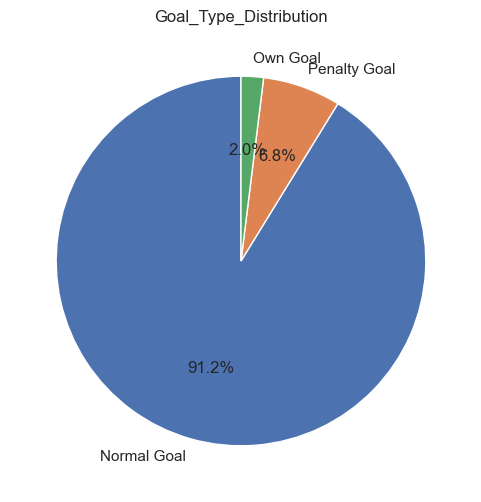

In [69]:
from IPython.display import display

# Display Table
display(goal_summary)

# Pie Chart
plt.figure(figsize=(6,6))

plt.pie(goal_summary['Goals'], labels=goal_summary['Goal Type'], autopct='%1.1f%%', startangle=90)

plt.title("Goal_Type_Distribution")

plt.show()

##### Observation:
This distribution proves that international football success relies primarily on open-play execution, while low penalty and own-goal counts underscore elite defenders' strict tactical restraint and technical competence.

# merged_df - Data Integration & Analytical Pipeline
Combining results and goalscorers datasets to track regular match outcomes alongside individual player goal trends

In [70]:
merged_df = goalscorers.merge(
           results[['date', 'home_team', 'away_team', 'tournament']],
           on=['date', 'home_team', 'away_team'],
           how='left')

merged_df.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year,Goal Type,tournament
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,1916,Normal Goal,Copa América
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,1916,Normal Goal,Copa América
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,1916,Normal Goal,Copa América
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,1916,Normal Goal,Copa América
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,1916,Normal Goal,Copa América


In [71]:
print("Rows in goalscorers :", goalscorers.shape[0])
print("Rows after merge    :", merged_df.shape[0])

Rows in goalscorers : 47824
Rows after merge    : 47824


## Average Goals per Match by Tournament

In [72]:
matches_per_tournament = (
    results.groupby('tournament').size()
    .reset_index(name='Matches'))

In [73]:
goals_per_tournament = (
    merged_df.groupby('tournament').size()
    .reset_index(name='Goals'))

In [74]:
avg_goals = (matches_per_tournament.merge(goals_per_tournament, on='tournament'))

avg_goals['Average Goals per Match'] = round(avg_goals['Goals'] / avg_goals['Matches'],2)

avg_goals = (avg_goals.sort_values(by='Average Goals per Match', ascending=False))

avg_goals.head(10)

,tournament,Matches,Goals,Average Goals per Match
13,NAFC Championship,6,26,4.33
14,Oceania Nations Cup,139,532,3.83
9,Copa América qualification,8,26,3.25
8,Copa América,869,2726,3.14
7,Confederations Cup,140,423,3.02
11,FIFA World Cup qualification,8771,25199,2.87
15,Olympic Games,78,224,2.87
18,UEFA Euro qualification,2824,7985,2.83
10,FIFA World Cup,1068,3017,2.82
12,Gold Cup,420,1182,2.81


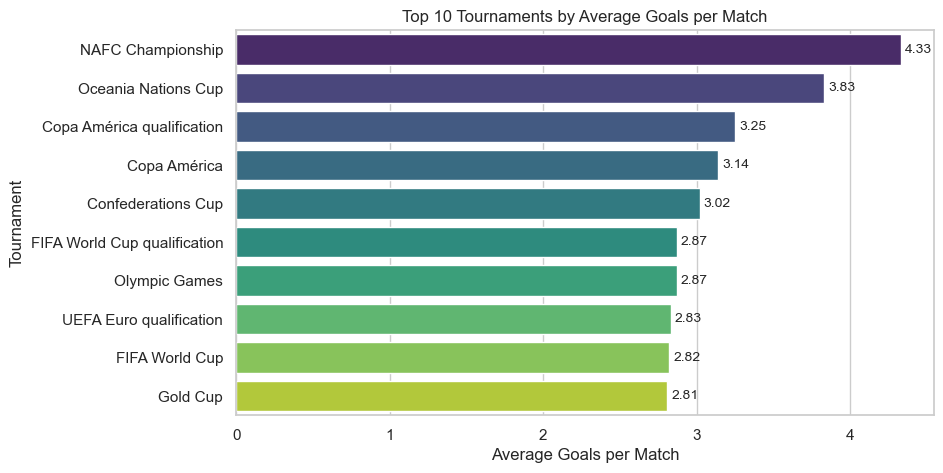

In [75]:
plt.figure(figsize=(9,5))

data = avg_goals.head(10)

ax = sns.barplot(data=data, x='Average Goals per Match', y='tournament', hue='tournament', palette='viridis', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, padding=3)

plt.title("Top 10 Tournaments by Average Goals per Match")
plt.xlabel("Average Goals per Match")
plt.ylabel("Tournament")

plt.show()

##### Key Insights:
- Major tournaments like FIFA World Cup and Gold Cup maintain more balanced competition with stronger teams, resulting in more consistent goal averages while promoting international football competition.
- Smaller tournaments such as NAFC Championship and Oceania Nations Cup show higher average goals per match, as these values are influenced by smaller sample sizes, a few high-scoring matches, differences in team strength, and more open attacking styles leading to higher goal rates.

## Top Goal Scorers by Tournament
To analyze player performance in various international competitions

In [76]:
tournament_scorers = (
    merged_df[merged_df['own_goal'] == False]
    .groupby(['tournament', 'scorer']).size()
    .reset_index(name='Goals'))

#### Top 10 tournament scorers

In [77]:
top10_tournament_scorers = (tournament_scorers
    .sort_values(['tournament', 'Goals'], ascending=[True, False])
    .drop_duplicates(subset='tournament')).sort_values(by='Goals', ascending=False).head(10)

top10_tournament_scorers

,tournament,scorer,Goals
6886,FIFA World Cup qualification,Cristiano Ronaldo,41
17343,UEFA Euro qualification,Cristiano Ronaldo,41
4306,FIFA World Cup,Lionel Messi,21
20316,UEFA Nations League,Erling Haaland,19
1429,African Cup of Nations,Samuel Eto'o,18
15697,Gold Cup,Landon Donovan,18
3113,Copa América,Norberto Doroteo Méndez,17
16375,UEFA Euro,Cristiano Ronaldo,14
39,AFC Asian Cup,Ali Daei,14
15998,Oceania Nations Cup,Damian Mori,13


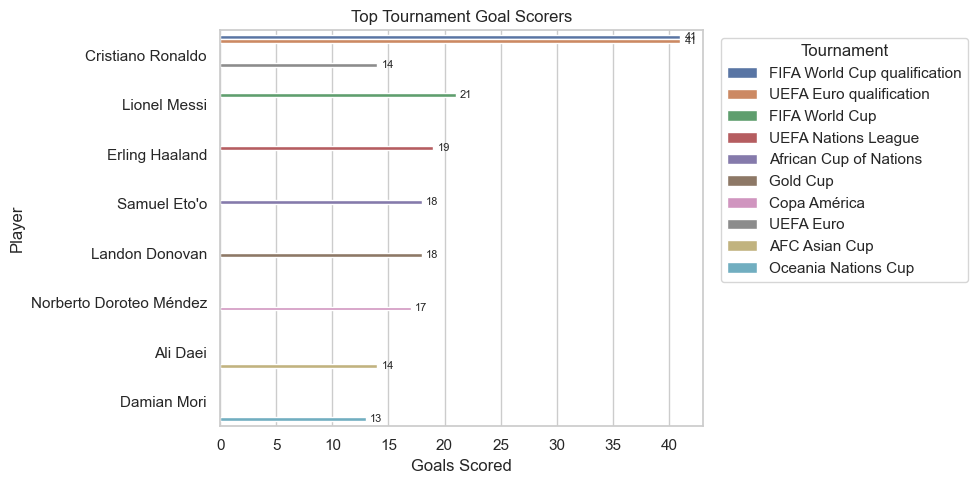

In [78]:
plt.figure(figsize=(10,5))

ax = sns.barplot(data=top10_tournament_scorers, x='Goals', y='scorer', hue='tournament', dodge=True)

plt.title("Top Tournament Goal Scorers")
plt.xlabel("Goals Scored")
plt.ylabel("Player")

plt.legend(title="Tournament", bbox_to_anchor=(1.02,1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

####Observation:
Cristiano Ronaldo dominated international football by emerging as the top scorer in both FIFA World Cup Qualification and UEFA Euro Qualification, highlighting his exceptional consistency in qualification campaigns, while Lionel Messi led the scoring charts in the FIFA World Cup, emphasizes his efficiency and clutch delivery during football's most critical knockout matches that maximizes the competitive value of his goals.

# Feature Schema: shootouts.csv

In [79]:
print("Rows, Columns :", shootouts.shape)

Rows, Columns : (683, 5)


In [80]:
shootouts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           683 non-null    object
 1   home_team      683 non-null    object
 2   away_team      683 non-null    object
 3   winner         683 non-null    object
 4   first_shooter  260 non-null    object
dtypes: object(5)
memory usage: 26.8+ KB


In [81]:
shootouts['date'] = pd.to_datetime(shootouts['date'])

In [82]:
shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [83]:
shootouts.isnull().sum()

date               0
home_team          0
away_team          0
winner             0
first_shooter    423
dtype: int64

In [84]:
shootouts = shootouts.drop(columns='first_shooter')

## Top Shootout Winners

In [85]:
top_shootout_winners = (shootouts['winner'].value_counts().reset_index())

top_shootout_winners.columns = ['Team', 'Shootout Wins']

top_shootout_winners.head(10)

,Team,Shootout Wins
0,Egypt,16
1,South Korea,15
2,Argentina,15
3,Zambia,14
4,South Africa,13
5,Thailand,13
6,Iraq,11
7,Senegal,11
8,Indonesia,10
9,Iran,10


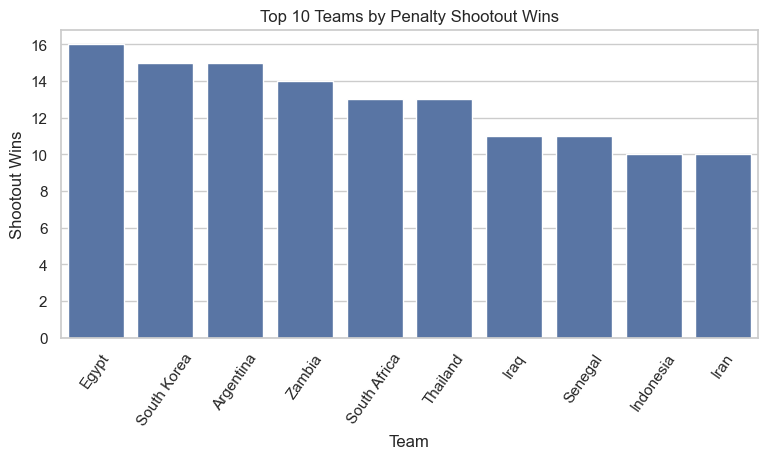

In [86]:
plt.figure(figsize=(9,4))

sns.barplot(data=top_shootout_winners.head(10), x='Team', y='Shootout Wins')

plt.title("Top 10 Teams by Penalty Shootout Wins")
plt.xlabel("Team")
plt.ylabel("Shootout Wins")

plt.xticks(rotation=55)

plt.show()

##### Observation:
Egypt, South Korea, and Argentina have the highest number of penalty shootout victories, demonstrating consistent success in high-pressure knockout situations.

# competitive_df - Data Integration 
Combining results and shootouts datasets to track regular match outcomes alongside penalty tie-breakers

In [87]:
competitive_df = shootouts.merge(
    results[['date', 'home_team', 'away_team', 'tournament']],
    on=['date', 'home_team', 'away_team'],
    how='left')

In [88]:
competitive_df.head()

,date,home_team,away_team,winner,tournament
0,1967-08-22,India,Taiwan,Taiwan,Merdeka Tournament
1,1971-11-14,South Korea,Vietnam Republic,South Korea,King's Cup
2,1972-05-07,South Korea,Iraq,Iraq,AFC Asian Cup
3,1972-05-17,Thailand,South Korea,South Korea,AFC Asian Cup
4,1972-05-19,Thailand,Cambodia,Thailand,AFC Asian Cup


## Most Competitive Tournaments
To identify the tournaments with the highest number of matches decided by penalty shootouts, indicating closely contested knockout games.

In [89]:
most_competitive = (competitive_df['tournament'].value_counts().reset_index())

most_competitive.columns = ['Tournament', 'Penalty Shootouts']

most_competitive.head(10)

,Tournament,Penalty Shootouts
0,Friendly,79
1,COSAFA Cup,63
2,African Cup of Nations,47
3,FIFA World Cup,39
4,Copa América,33
5,African Cup of Nations qualification,28
6,AFC Asian Cup,27
7,UEFA Euro,25
8,FIFA World Cup qualification,21
9,Gold Cup,18


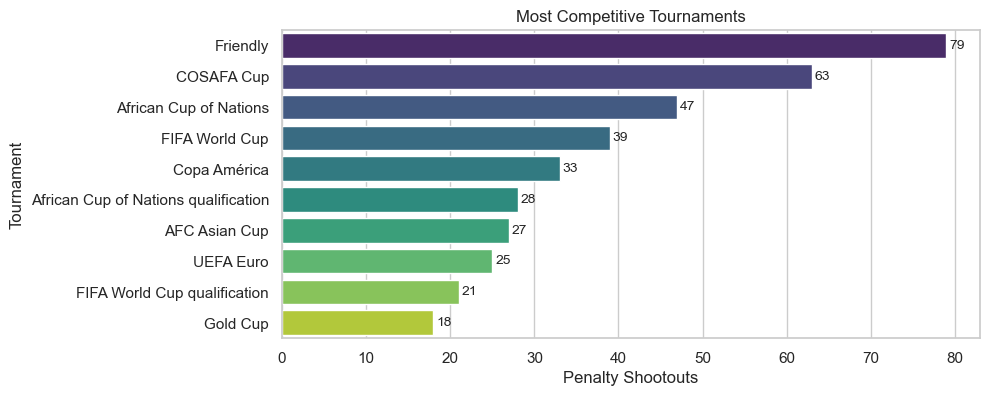

In [90]:
plt.figure(figsize=(9,4))

ax = sns.barplot(data=most_competitive.head(10), x='Penalty Shootouts', y='Tournament',
                 hue='Tournament', palette='viridis', legend=False)

plt.title("Most Competitive Tournaments")
plt.xlabel("Penalty Shootouts")
plt.ylabel("Tournament")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2, fontsize=10)

plt.show()

##### Key Insights:
- Friendly matches (79) recorded the highest number of penalty shootouts, primarily due to their large match volume, as observed in the results dataset.
- Regional competitions such as the COSAFA Cup (63) also witnessed frequent shootouts, reflecting closely contested matches and tournament formats that often proceed directly to penalties.
- Major international tournaments, including the African Cup of Nations (47), FIFA World Cup (39), Copa América (33), and UEFA Euro (25), regularly reached penalty shootouts, highlighting the intense competition and narrow margins in knockout-stage football.

# shootout_goals - Data Integration
Combining shootouts and goalscorers datasets to get insights on player-level goal details alongside penalty shootout outcomes

In [91]:
shootout_goals = goalscorers.merge(
    shootouts[['date', 'home_team', 'away_team', 'winner']],
    on=['date', 'home_team', 'away_team'],
    how='inner')

shootout_goals.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year,Goal Type,winner
0,1972-05-17,Thailand,South Korea,Thailand,Prapon Tantariyanond,98.0,False,False,1972,Normal Goal,South Korea
1,1972-05-17,Thailand,South Korea,South Korea,Park Lee-chun,115.0,False,False,1972,Normal Goal,South Korea
2,1972-05-19,Thailand,Cambodia,Thailand,Ich Narding,6.0,False,False,1972,Normal Goal,Thailand
3,1972-05-19,Thailand,Cambodia,Cambodia,Tol Kimchi,44.0,False,False,1972,Normal Goal,Thailand
4,1972-05-19,Thailand,Cambodia,Cambodia,Tol Kimchi,49.0,False,False,1972,Normal Goal,Thailand


## Top Goal Scorers in Penalty Shootout Matches

Objective:
To identify the players who scored the most goals in matches that were eventually decided by penalty shootouts, highlighting performers in high-pressure game.

In [92]:
top_shootout_scorers = (shootout_goals.groupby(['scorer', 'team']).size()
    .reset_index(name='Goals')
    .nlargest(10, 'Goals'))

top_shootout_scorers['Player (Country)'] = (top_shootout_scorers['scorer'] + " (" + top_shootout_scorers['team'] + ")")

top_shootout_scorers = top_shootout_scorers[['Player (Country)', 'Goals']]

top_shootout_scorers

,Player (Country),Goals
146,Jamil Joseph (Saint Lucia),3
188,Kylian Mbappé (France),3
198,Lionel Messi (Argentina),3
0,A'ala Hubail (Bahrain),2
6,Adriano (Brazil),2
9,Alan Shearer (England),2
22,Ali Zitouni (Tunisia),2
31,Aristide Bancé (Burkina Faso),2
47,Bryan Ruiz (Costa Rica),2
55,Claudio Caniggia (Argentina),2


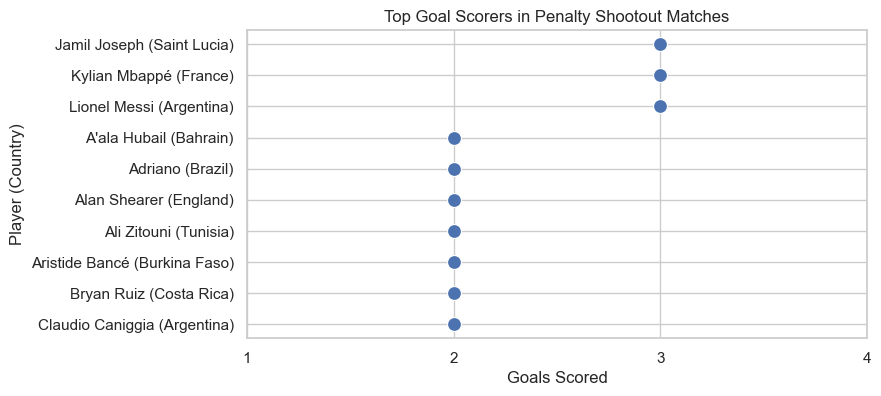

In [93]:
plt.figure(figsize=(8,4))

sns.scatterplot(data=top_shootout_scorers, x='Goals', y='Player (Country)', s=100)

plt.title("Top Goal Scorers in Penalty Shootout Matches")
plt.xlabel("Goals Scored")
plt.ylabel("Player (Country)")

plt.xlim(1, 4)
plt.xticks([1, 2, 3, 4])

plt.show()

#### Key Insights:
• The low goal counts indicate that penalty shootout matches are generally tightly contested, with most players scoring only 2–3 goals across such 
high-pressure encounters
• Jamil Joseph, Lionel Messi, and Kylian Mbappé jointly top the list with three goals each, demonstrating the importance of key attacking players in
closely contested matches that eventually extend to penalty shootouts.

### Overall EDA Conclusion

• International football matches have increased significantly over the years, reflecting the global growth and popularity of the sport.

• FIFA World Cup Qualification and UEFA Euro Qualification hosted the highest number of matches and recorded the most goals due to their extensive qualification formats.

• Most international matches are closely contested, averaging 2–3 goals per match, while only a few tournaments exhibit exceptionally high-scoring games.

• Normal goals account for the vast majority of scoring events, whereas penalty and own goals contribute only a small percentage.

• Goal-scoring records are concentrated among a few legendary players, while tournament-specific analyses highlight both established stars and emerging talents.

• Penalty shootout matches are relatively rare and mainly occur in knockout tournaments, emphasizing the highly competitive nature of these fixtures.

## Summary:
The exploratory data analysis provides a comprehensive understanding of international football trends, player performances, tournament characteristics,
and match outcomes, enabling data-driven insights into the evolution and competitiveness of international football.

# Football Player Career Performance Analysis Using Data Analytics

In [95]:
goalscorers['scorer'].value_counts().head(20)

scorer
Cristiano Ronaldo      124
Harry Kane              75
Lionel Messi            71
Robert Lewandowski      68
Romelu Lukaku           67
Edin Džeko              58
Kylian Mbappé           53
Erling Haaland          53
Aleksandar Mitrović     52
Luis Suárez             51
Ali Daei                49
Miroslav Klose          48
Carlos Ruiz             47
Zlatan Ibrahimović      44
Memphis Depay           44
Robbie Keane            44
Clint Dempsey           41
David Villa             41
Andriy Shevchenko       40
Samuel Eto'o            40
Name: count, dtype: int64

# Career Analysis – Lionel Messi

## Why Lionel Messi?

Lionel Messi was selected for this analysis because of his exceptional international career, consistent goal-scoring record,
and significant contributions across multiple tournaments. His long career timeline provides an excellent opportunity to study performance evolution,
identify peak years, and analyze major career milestones.

In [96]:
# Select Lionel Messi's international goal records

player_name = "Lionel Messi"

messi_df = goalscorers[
    goalscorers["scorer"] == player_name
].copy()

messi_df.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year,Goal Type
26136,2006-06-16,Argentina,Serbia,Argentina,Lionel Messi,88.0,False,False,2006,Normal Goal
26839,2007-07-08,Argentina,Peru,Argentina,Lionel Messi,61.0,False,False,2007,Normal Goal
26871,2007-07-11,Mexico,Argentina,Argentina,Lionel Messi,61.0,False,False,2007,Normal Goal
27183,2007-10-16,Venezuela,Argentina,Argentina,Lionel Messi,43.0,False,False,2007,Normal Goal
27452,2007-11-20,Colombia,Argentina,Argentina,Lionel Messi,36.0,False,False,2007,Normal Goal


In [140]:
# Check total international goals in the dataset

print("Player :", player_name)
print("Total Goals :", len(messi_df))

Player : Lionel Messi
Total Goals : 71


In [98]:
messi_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71 entries, 26136 to 47884
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       71 non-null     datetime64[ns]
 1   home_team  71 non-null     object        
 2   away_team  71 non-null     object        
 3   team       71 non-null     object        
 4   scorer     71 non-null     object        
 5   minute     71 non-null     float64       
 6   own_goal   71 non-null     bool          
 7   penalty    71 non-null     bool          
 8   year       71 non-null     int32         
 9   Goal Type  71 non-null     object        
dtypes: bool(2), datetime64[ns](1), float64(1), int32(1), object(5)
memory usage: 4.9+ KB


In [99]:
messi_df.describe(include='all')

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year,Goal Type
count,71,71,71,71,71,71.00000,71,71,71.000000,71
unique,NaN,12,23,1,1,NaN,1,2,NaN,2
top,NaN,Argentina,Argentina,Argentina,Lionel Messi,NaN,False,False,NaN,Normal Goal
freq,NaN,53,18,71,71,NaN,71,57,NaN,57
mean,2018-09-13 13:51:32.957746432,NaN,NaN,NaN,NaN,48.71831,NaN,NaN,2018.084507,NaN
min,2006-06-16 00:00:00,NaN,NaN,NaN,NaN,3.00000,NaN,NaN,2006.000000,NaN
25%,2014-06-18 00:00:00,NaN,NaN,NaN,NaN,28.50000,NaN,NaN,2014.000000,NaN
50%,2019-06-19 00:00:00,NaN,NaN,NaN,NaN,43.00000,NaN,NaN,2019.000000,NaN
75%,2022-12-18 00:00:00,NaN,NaN,NaN,NaN,70.50000,NaN,NaN,2022.000000,NaN
max,2026-07-07 00:00:00,NaN,NaN,NaN,NaN,109.00000,NaN,NaN,2026.000000,NaN


In [100]:
print("Career Starts :", messi_df["year"].min())
print("Latest Year   :", messi_df["year"].max())

Career Starts : 2006
Latest Year   : 2026


## Player Career Overview

Lionel Messi's international goal-scoring record spans from **2006 to 2026**, covering approximately **20 years** of international football.

The dataset contains **71 international goals**, making it suitable for analyzing long-term performance trends, peak years, scoring consistency, 
and career evolution.

In [137]:
# Year-wise international goals scored by Lionel Messi

career = (
    messi_df
    .groupby("year")
    .size()
    .reset_index(name="Goals")
    .sort_values("year"))

career

,year,Goals
0,2006,1
1,2007,4
2,2008,1
3,2009,1
4,2011,2
5,2012,5
6,2013,3
7,2014,4
8,2015,1
9,2016,8


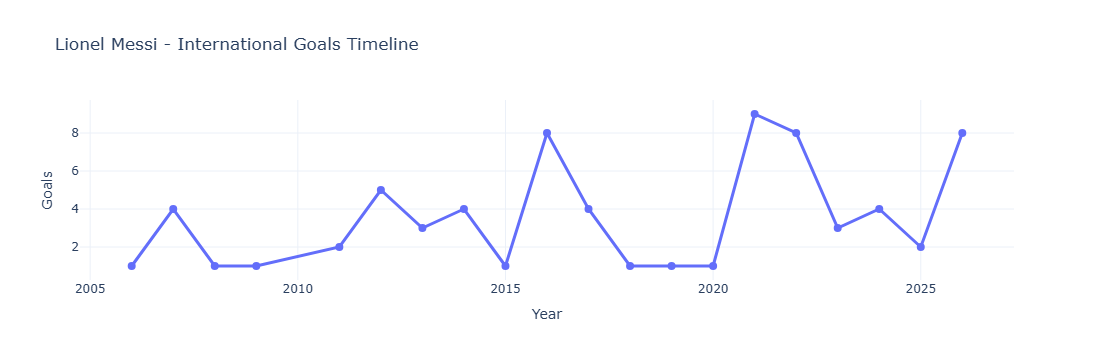

In [136]:
import plotly.express as px

fig = px.line(
    career,
    x="year",
    y="Goals",
    markers=True,
    title="Lionel Messi - International Goals Timeline")

fig.update_traces(line_width=3, marker_size=8)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Goals",
    template="plotly_white")

fig.show()

### Career Evolution Analysis

Lionel Messi's international career can be divided into six distinct phases:

- Early Development Phase (2006–2011)
- Performance Growth Phase (2012–2015)
- Prime Scoring Phase (2016–2017)
- Transitional Phase (2018–2020)
- Peak International Success (2021–2022)
- Experienced Leadership Phase (2023–2026)

Overall, Messi's career reflects steady development, remarkable consistency during his prime years, and sustained high-level performance over 
nearly two decades of international football.

## Career Timeline Analysis

The chart illustrates Lionel Messi's year-wise international goal-scoring performance.

This timeline helps identify:
- Performance growth over time
- Peak scoring years
- Decline or recovery phases
- Career consistency

### Best & Worst Career Years

In [103]:
# Best scoring year
best_year = career.loc[career["Goals"].idxmax()]

# Lowest scoring year
worst_year = career.loc[career["Goals"].idxmin()]

print("Best Year")
print(best_year)

print("\nWorst Year")
print(worst_year)

Best Year
year     2021
Goals       9
Name: 14, dtype: int64

Worst Year
year     2006
Goals       1
Name: 0, dtype: int64


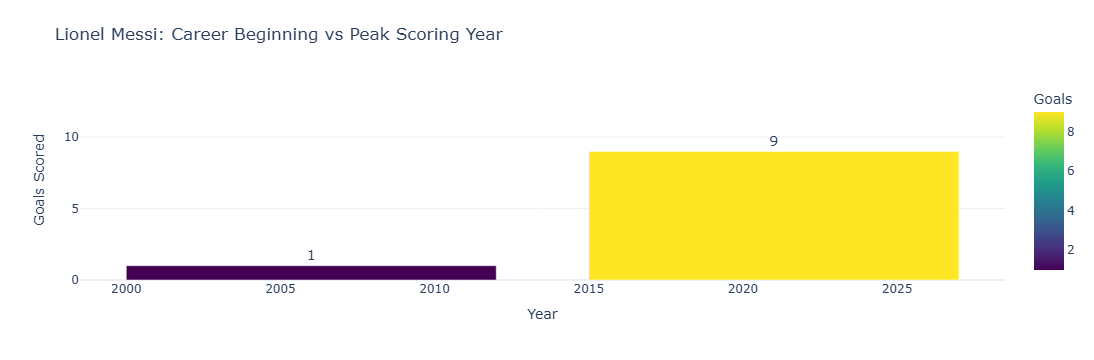

In [134]:
import plotly.express as px

comparison = career[
    career["year"].isin([2006, 2021])]

fig = px.bar(
    comparison,
    x="year",
    y="Goals",
    text="Goals",
    color="Goals",
    color_continuous_scale="Viridis",
    title="Lionel Messi: Career Beginning vs Peak Scoring Year")

fig.update_traces(
    textposition="outside",
    textfont_size=14)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Goals Scored",
    template="plotly_white",
    yaxis=dict(
        range=[0, max(comparison["Goals"]) + 5] ),
    margin=dict(
        t=80))

fig.show()

### Observation

- Lionel Messi scored only **1 goal** during the beginning of his international career in **2006**.
- His highest international goal tally came in **2021**, when he scored **9 goals**.
- This comparison reflects his remarkable growth, consistency, and evolution into one of football's greatest international goal scorers.

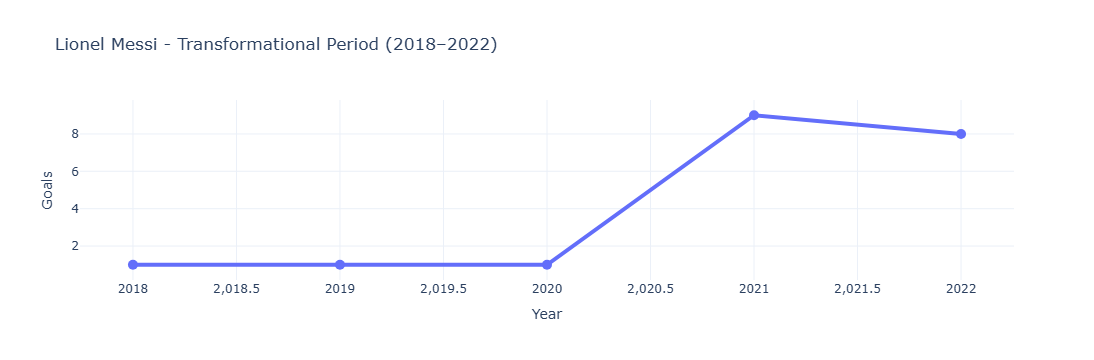

In [131]:
import plotly.express as px

transform_df = career[
    (career["year"] >= 2018) &
    (career["year"] <= 2022)]

fig = px.line(
    transform_df,
    x="year",
    y="Goals",
    markers=True,
    title="Lionel Messi - Transformational Period (2018–2022)")

fig.update_traces(line_width=4, marker_size=10)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Year",
    yaxis_title="Goals")

fig.show()

### Transformational Period Analysis

The period between **2020 and 2022** represents the most significant transformation in Lionel Messi's international career.

After recording only **1 international goal in 2020**, Messi's performance improved dramatically, reaching **9 goals in 2021** and 
maintaining **8 goals in 2022**.

This remarkable rise reflects one of the strongest phases of his international career and highlights his ability to deliver consistently during 
major international competitions.

### Key Career Milestones

- Won the **2021 Copa America**, securing his first major international trophy with Argentina.
- Delivered outstanding performances throughout the tournament and emerged as one of the team's most influential players.
- Continued this momentum into **2022**, playing a decisive role in Argentina's **FIFA World Cup-winning campaign**.
- These achievements marked the peak of his international career and strengthened his legacy as one of football's greatest players.

In [138]:
# Create Lionel Messi career dataset

player_name = "Lionel Messi"

messi_df = merged_df[
    merged_df["scorer"] == player_name].copy()

messi_df.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year,Goal Type,tournament
26062,2006-06-16,Argentina,Serbia,Argentina,Lionel Messi,88.0,False,False,2006,Normal Goal,FIFA World Cup
26765,2007-07-08,Argentina,Peru,Argentina,Lionel Messi,61.0,False,False,2007,Normal Goal,Copa América
26797,2007-07-11,Mexico,Argentina,Argentina,Lionel Messi,61.0,False,False,2007,Normal Goal,Copa América
27109,2007-10-16,Venezuela,Argentina,Argentina,Lionel Messi,43.0,False,False,2007,Normal Goal,FIFA World Cup qualification
27378,2007-11-20,Colombia,Argentina,Argentina,Lionel Messi,36.0,False,False,2007,Normal Goal,FIFA World Cup qualification


In [139]:
# Tournament-wise Goals

tournament_goals = (
    messi_df
    .groupby("tournament")
    .size()
    .reset_index(name="Goals")
    .sort_values("Goals", ascending=False))

tournament_goals

,tournament,Goals
2,FIFA World Cup qualification,36
1,FIFA World Cup,21
0,Copa América,14


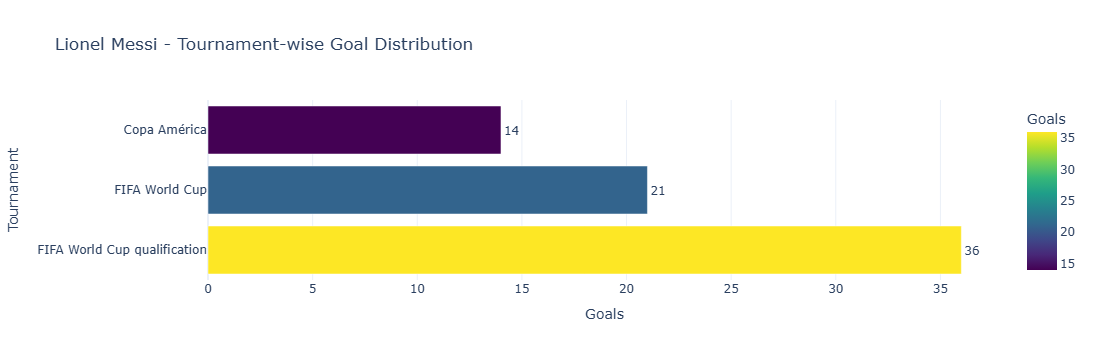

In [129]:
import plotly.express as px

fig = px.bar(
    tournament_goals,
    x="Goals",
    y="tournament",
    orientation="h",
    text="Goals",
    color="Goals",
    color_continuous_scale="Viridis",
    title="Lionel Messi - Tournament-wise Goal Distribution")

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    xaxis_title="Goals",
    yaxis_title="Tournament")

fig.show()

### Tournament Performance Analysis

Lionel Messi scored international goals across **three major competitions**.

- **FIFA World Cup Qualification** was his most productive competition, with **36 goals**, highlighting his consistent performances during 
    qualification campaigns.
- He scored **21 goals in the FIFA World Cup**, demonstrating his ability to perform on football's biggest stage.
- In **Copa América**, Messi registered **14 goals**, making significant contributions in South America's premier international tournament.

Overall, Messi maintained a strong scoring record across both qualification matches and major international tournaments, reflecting his consistency 
and longevity at the highest level.

In [110]:
goal_type = (
    messi_df["Goal Type"]
    .value_counts()
    .reset_index()
)

goal_type.columns = ["Goal Type", "Goals"]

goal_type

,Goal Type,Goals
0,Normal Goal,57
1,Penalty Goal,14


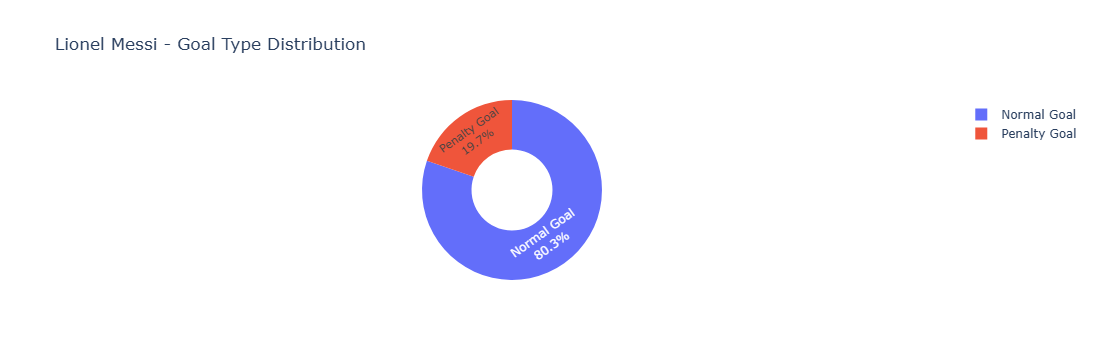

In [128]:
import plotly.express as px

fig = px.pie(
    goal_type,
    names="Goal Type",
    values="Goals",
    hole=0.45,
    title="Lionel Messi - Goal Type Distribution")

fig.update_traces(
    textposition="inside",
    textinfo="percent+label")

fig.show()

### Goal Type Analysis

- Lionel Messi scored the majority of his international goals through **open play**, with **57 normal goals**, highlighting his creativity, positioning, and finishing ability.

- He also converted **14 penalty goals**, demonstrating composure and reliability in high-pressure situations.

- The distribution indicates that Messi's goal-scoring success has primarily been driven by overall attacking play rather than penalties alone.

In [127]:
# Create Match Venue

messi_df["Match Venue"] = messi_df.apply(
    lambda x: "Home"
    if x["team"] == x["home_team"]
    else "Away",
    axis=1)

messi_df[["team", "home_team", "away_team", "Match Venue"]].head()

,team,home_team,away_team,Match Venue
26062,Argentina,Argentina,Serbia,Home
26765,Argentina,Argentina,Peru,Home
26797,Argentina,Mexico,Argentina,Away
27109,Argentina,Venezuela,Argentina,Away
27378,Argentina,Colombia,Argentina,Away


In [113]:
venue_goals = (
    messi_df["Match Venue"]
    .value_counts()
    .reset_index()
)

venue_goals.columns = ["Venue", "Goals"]

venue_goals

,Venue,Goals
0,Home,53
1,Away,18


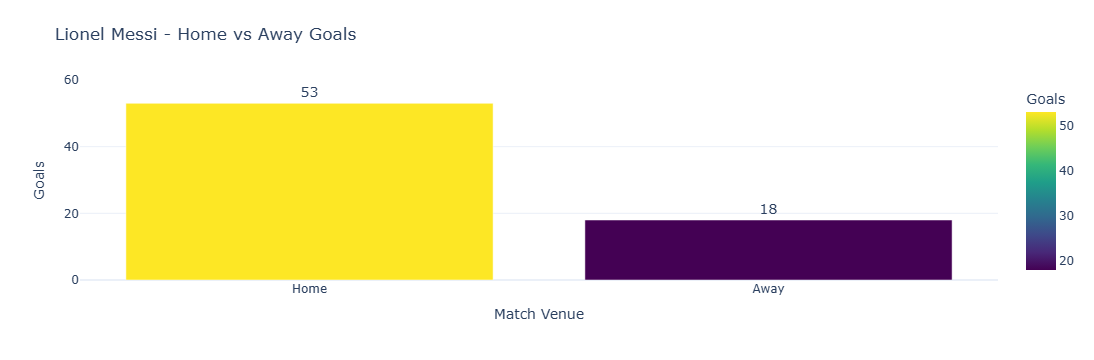

In [126]:
import plotly.express as px

fig = px.bar(
    venue_goals,
    x="Venue",
    y="Goals",
    text="Goals",
    color="Goals",
    color_continuous_scale="Viridis",
    title="Lionel Messi - Home vs Away Goals")

fig.update_traces(
    textposition="outside",
    textfont_size=14)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Match Venue",
    yaxis_title="Goals",
    yaxis=dict(
        range=[0, 60]),
    margin=dict(
        t=80))

fig.show()

### Home vs Away Performance Analysis

Lionel Messi scored **53 goals in home matches** and **18 goals in away matches** throughout his international career.

The higher goal tally in home fixtures suggests greater attacking productivity in familiar playing conditions. However, his **18 away goals** 
demonstrate his ability to consistently perform and contribute even in challenging environments, reflecting his adaptability and world-class consistency across different venues.

In [115]:
opponent_goals = (
    messi_df["away_team"]
    .where(messi_df["team"] == messi_df["home_team"], messi_df["home_team"])
    .value_counts()
    .reset_index()
)

opponent_goals.columns = ["Opponent", "Goals"]

opponent_goals.head(10)

,Opponent,Goals
0,Bolivia,9
1,Venezuela,7
2,Ecuador,7
3,Uruguay,5
4,Chile,5
5,Paraguay,5
6,Panama,3
7,Algeria,3
8,Colombia,3
9,Peru,3


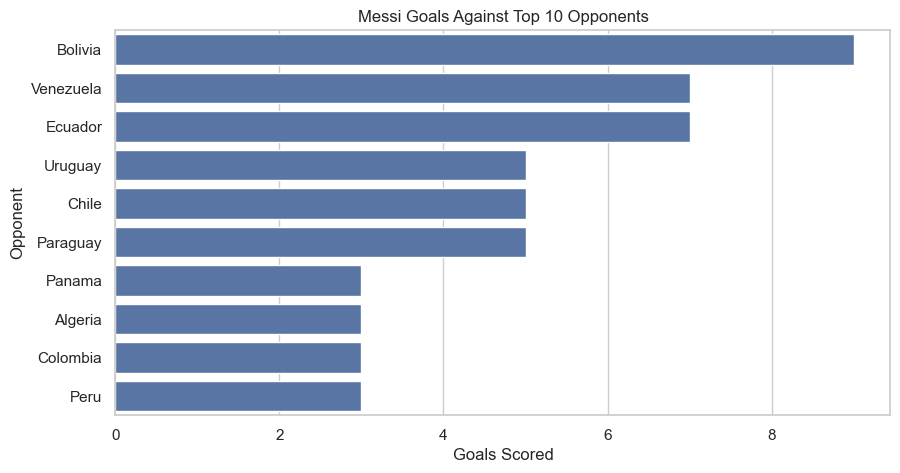

In [116]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=opponent_goals.head(10),
    x="Goals",
    y="Opponent"
)

plt.title("Messi Goals Against Top 10 Opponents")
plt.xlabel("Goals Scored")
plt.ylabel("Opponent")

plt.show()

### Opponent Analysis

Lionel Messi has scored against a wide range of international opponents, demonstrating his consistency across different competitions.

- **Bolivia** was his most successful opponent with **9 goals**.
- He also scored **7 goals** each against **Venezuela** and **Ecuador**.
- Strong performances against **Uruguay, Chile, and Paraguay** further highlight his effectiveness against top South American teams.

This distribution reflects Messi's long-term dominance in CONMEBOL competitions and FIFA World Cup qualification campaigns.

In [117]:
minute_goals = (
    messi_df["minute"]
    .value_counts()
    .sort_index()
    .reset_index()
)

minute_goals.columns = ["Minute", "Goals"]

minute_goals.head()

,Minute,Goals
0,3.0,1
1,6.0,1
2,10.0,2
3,11.0,1
4,12.0,1


In [123]:
# Function to classify goals by match period

def goal_period(minute):

    if minute <= 30:
        return "Early Game (0–30')"

    elif minute <= 60:
        return "Mid Game (31–60')"

    else:
        return "Late Game (61+')"


# Create Goal Period column
messi_df["Goal Period"] = messi_df["minute"].apply(goal_period)

# Count goals in each period
period_goals = (
    messi_df["Goal Period"]
    .value_counts()
    .reset_index())

period_goals.columns = ["Period", "Goals"]

# Arrange in correct order
period_order = [
    "Early Game (0–30')",
    "Mid Game (31–60')",
    "Late Game (61+')"
]

period_goals["Period"] = pd.Categorical(
    period_goals["Period"],
    categories=period_order,
    ordered=True
)

period_goals = period_goals.sort_values("Period")

period_goals

,Period,Goals
2,Early Game (0–30'),20
1,Mid Game (31–60'),23
0,Late Game (61+'),28


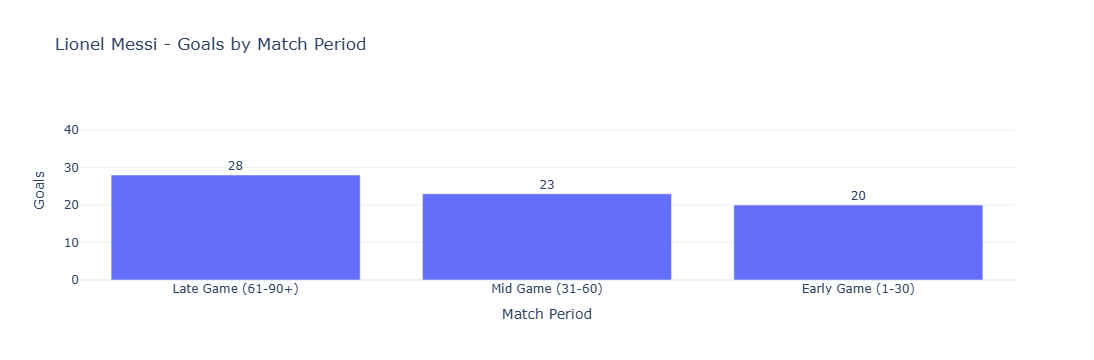

In [122]:
fig.update_traces(
    texttemplate="%{y}",
    textposition="outside",
    cliponaxis=False
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Match Period",
    yaxis_title="Goals",
    yaxis_range=[0, half_goals["Goals"].max() + 10]
)

## Goal Timing Analysis

Lionel Messi's international goals were analyzed based on the period of the match in which they were scored to understand his scoring behavior across different stages of play.

### Key Insights

- Messi remained an effective goal scorer throughout the match, contributing in the **early, middle, and late phases**.
- His goal distribution shows that he was capable of creating scoring opportunities regardless of the match stage.
- The strong presence in the **late stages** highlights his ability to influence important moments when matches become more competitive.
- The balanced scoring pattern reflects his consistency, tactical awareness, and endurance over the full duration of a game.


Messi's goal-scoring pattern demonstrates his ability to remain a constant attacking threat from kickoff until the final whistle, showcasing exceptional consistency and match-winning impact throughout his international career.

## Final Conclusion

• This analysis provides a comprehensive overview of Lionel Messi's international football career using data-driven insights.

• The study highlights Messi's evolution from a young emerging talent to one of the greatest footballers in international history.

• The analysis identified key performance areas including:
   - Career growth and peak scoring years
   - Tournament-wise contributions
   - Opponent-wise goal performance
   - Home vs away consistency
   - Goal timing and scoring patterns

• Messi demonstrated exceptional consistency over nearly two decades, maintaining a high level of performance across different competitions and match conditions.

• The 2021 Copa America victory and 2022 FIFA World Cup campaign emerged as defining phases of his international career, showcasing his leadership, adaptability, and ability to perform under pressure.

• The findings indicate that Messi's success was built on sustained excellence, technical ability, and consistent contribution rather than isolated performances.

• Overall, this analysis reinforces Lionel Messi's legacy as one of the most influential and impactful players in modern international football.